In [1]:
!pip install -q streamlit fastapi uvicorn python-multipart pypdf requests langchain-groq langgraph pydantic supabase pyngrok

In [2]:
%%writefile backend.py
import io
from typing import Optional, TypedDict
from pydantic import BaseModel, Field
from pypdf import PdfReader
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from supabase import create_client

# --- 1. SUPABASE SETUP ---
SUPABASE_URL = "https://pylmyddtswqatdcxprnn.supabase.co"
SUPABASE_KEY = "s...........................hlNsFaBL"
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# --- 2. LANGGRAPH SCHEMAS ---
class ComplaintData(BaseModel):
    complaint_source: Optional[str] = Field(default=None)
    customer_name: Optional[str] = Field(default=None)
    product_name: Optional[str] = Field(default=None)
    product_strength: Optional[str] = Field(default=None)
    batch_lot_number: Optional[str] = Field(default=None)
    affected_quantity: Optional[str] = Field(default=None)
    manufacturing_date: Optional[str] = Field(default=None)
    expiry_date: Optional[str] = Field(default=None)

class GraphState(TypedDict):
    input_text: str
    extracted: Optional[ComplaintData]
    is_valid: bool
    retry_count: int
    error: Optional[str]
    db_id: Optional[int]

# --- 3. GROQ LLM SETUP ---
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key="gsk_NjC......SS4yLxVW"
)
structured_llm = llm.with_structured_output(ComplaintData)

EXTRACTION_PROMPT = """You are a data extraction assistant for a pharma company (Apollo Medicine).
Extract the following fields from the complaint text below. If a field is not
mentioned, leave it as null. Do not guess or invent values.

Fields: complaint_source, customer_name, product_name, product_strength,
batch_lot_number, affected_quantity, manufacturing_date, expiry_date

Complaint text:
\"\"\"{text}\"\"\"
"""

def extract_node(state: GraphState) -> GraphState:
    prompt = EXTRACTION_PROMPT.format(text=state["input_text"])
    try:
        result = structured_llm.invoke(prompt)
        return {**state, "extracted": result, "error": None}
    except Exception as e:
        return {**state, "extracted": None, "error": str(e)}

def validate_node(state: GraphState) -> GraphState:
    data = state.get("extracted")
    if data is None:
        return {**state, "is_valid": False}

    prod_name = getattr(data, "product_name", None) if not isinstance(data, dict) else data.get("product_name")
    batch_num = getattr(data, "batch_lot_number", None) if not isinstance(data, dict) else data.get("batch_lot_number")
    cust_name = getattr(data, "customer_name", None) if not isinstance(data, dict) else data.get("customer_name")

    required_ok = bool(prod_name) and bool(batch_num or cust_name)
    return {**state, "is_valid": required_ok}

def retry_router(state: GraphState) -> str:
    if state["is_valid"]:
        return "store"
    if state["retry_count"] >= 2:
        return "end"
    return "retry"

def increment_retry(state: GraphState) -> GraphState:
    return {**state, "retry_count": state["retry_count"] + 1}

def store_node(state: GraphState) -> GraphState:
    if not state.get("extracted"):
        return state

    ext = state["extracted"]
    if hasattr(ext, "model_dump"):
        data = ext.model_dump()
    elif hasattr(ext, "dict"):
        data = ext.dict()
    elif isinstance(ext, dict):
        data = ext
    else:
        return state

    try:
        response = supabase.table("complaints").insert(data).execute()
        row_id = response.data[0]["id"] if response.data else None
        return {**state, "db_id": row_id, "error": None}
    except Exception as e:
        return {**state, "db_id": None, "error": str(e)}

# Build LangGraph State Machine
graph = StateGraph(GraphState)
graph.add_node("extract", extract_node)
graph.add_node("validate", validate_node)
graph.add_node("increment_retry", increment_retry)
graph.add_node("store", store_node)

graph.add_edge(START, "extract")
graph.add_edge("extract", "validate")
graph.add_conditional_edges("validate", retry_router, {"retry": "increment_retry", "store": "store", "end": END})
graph.add_edge("increment_retry", "extract")
graph.add_edge("store", END)
langgraph_app = graph.compile()

# --- 4. BACKEND HELPER FUNCTIONS FOR FRONTEND ---

def parse_pdf(pdf_bytes: bytes) -> str:
    """Extracts text from PDF bytes using PyPDF."""
    pdf_file = io.BytesIO(pdf_bytes)
    reader = PdfReader(pdf_file)
    extracted_text = ""
    for page in reader.pages:
        extracted_text += page.extract_text() or ""
    return extracted_text.strip()

def process_text_complaint(text: str):
    """Processes text through LangGraph and stores in Supabase."""
    initial_state = {
        "input_text": text,
        "extracted": None,
        "is_valid": False,
        "retry_count": 0,
        "error": None,
        "db_id": None,
    }
    final_state = langgraph_app.invoke(initial_state)

    ext = final_state.get("extracted")
    if hasattr(ext, "model_dump"):
        ext_dict = ext.model_dump()
    elif hasattr(ext, "dict"):
        ext_dict = ext.dict()
    elif isinstance(ext, dict):
        ext_dict = ext
    else:
        ext_dict = None

    return {
        "extracted": ext_dict,
        "db_id": final_state.get("db_id"),
        "error": final_state.get("error")
    }

def process_pdf_complaint(pdf_bytes: bytes):
    """Parses PDF bytes, runs LangGraph extraction, and returns result."""
    raw_text = parse_pdf(pdf_bytes)
    if not raw_text:
        return {"error": "Could not extract text from PDF", "extracted": None, "db_id": None, "raw_text": ""}

    result = process_text_complaint(raw_text)
    result["raw_text"] = raw_text
    return result

def update_complaint_record(db_id: int, updated_data: dict):
    """Updates an existing complaint record in Supabase."""
    try:
        response = supabase.table("complaints").update(updated_data).eq("id", db_id).execute()
        return {"success": True, "data": response.data}
    except Exception as e:
        return {"success": False, "error": str(e)}

Overwriting backend.py


In [3]:
%%writefile app.py
import streamlit as st
from backend import process_text_complaint, process_pdf_complaint, update_complaint_record

st.set_page_config(page_title="AIVOA Complaint Manager", layout="wide")
st.title("💊 AI Customer Complaint Manager")

if "extracted_data" not in st.session_state:
    st.session_state.extracted_data = None
if "db_id" not in st.session_state:
    st.session_state.db_id = None

col1, col2 = st.columns([1, 1.2])

with col1:
    st.subheader("📥 Input Complaint")
    input_type = st.radio("Select Input Type:", ["Text Input", "PDF Document Upload"])

    if input_type == "Text Input":
        user_input = st.text_area("Paste Complaint Email / Transcript:", height=220, placeholder="e.g., Customer John Doe reported issue with Apollo Paracetamol batch #99211...")

        if st.button("Analyze Text with AI", type="primary"):
            if user_input.strip():
                with st.spinner("AI is analyzing and saving to Supabase..."):
                    result = process_text_complaint(user_input)
                    if result.get("extracted"):
                        st.session_state.extracted_data = result["extracted"]
                        st.session_state.db_id = result["db_id"]
                        st.success("Extraction Complete & Saved to Supabase!")
                    else:
                        st.error(f"Extraction failed: {result.get('error')}")
            else:
                st.warning("Please enter text first.")

    else:  # PDF Upload
        uploaded_file = st.file_uploader("Upload Pharma Complaint PDF:", type=["pdf"])

        if st.button("Extract & Analyze PDF", type="primary"):
            if uploaded_file is not None:
                with st.spinner("Extracting PDF text and analyzing via AI..."):
                    result = process_pdf_complaint(uploaded_file.getvalue())
                    if result.get("extracted"):
                        st.session_state.extracted_data = result["extracted"]
                        st.session_state.db_id = result["db_id"]
                        st.success("PDF Analyzed & Saved to Supabase!")
                        with st.expander("Show Extracted Raw Text from PDF"):
                            st.write(result.get("raw_text", ""))
                    else:
                        st.error(f"Failed to process PDF: {result.get('error')}")
            else:
                st.warning("Please upload a PDF file first.")

with col2:
    st.subheader("📋 Log Customer Complaint (Form)")
    st.markdown("Review and edit the AI-extracted data.")

    data = st.session_state.extracted_data or {}

    with st.form("complaint_form"):
        c1, c2 = st.columns(2)
        source = c1.text_input("Complaint Source", value=data.get("complaint_source") or "")
        customer = c2.text_input("Customer Name", value=data.get("customer_name") or "")

        c3, c4 = st.columns(2)
        product = c3.text_input("Product Name", value=data.get("product_name") or "")
        strength = c4.text_input("Product Strength", value=data.get("product_strength") or "")

        c5, c6 = st.columns(2)
        batch = c5.text_input("Batch/Lot Number", value=data.get("batch_lot_number") or "")
        quantity = c6.text_input("Affected Quantity", value=data.get("affected_quantity") or "")

        c7, c8 = st.columns(2)
        mfg_date = c7.text_input("Manufacturing Date", value=data.get("manufacturing_date") or "")
        exp_date = c8.text_input("Expiry Date", value=data.get("expiry_date") or "")

        submitted = st.form_submit_button("Update Database Record")

        if submitted:
            if st.session_state.db_id:
                updated_payload = {
                    "complaint_source": source,
                    "customer_name": customer,
                    "product_name": product,
                    "product_strength": strength,
                    "batch_lot_number": batch,
                    "affected_quantity": quantity,
                    "manufacturing_date": mfg_date,
                    "expiry_date": exp_date
                }
                res = update_complaint_record(st.session_state.db_id, updated_payload)
                if res.get("success"):
                    st.success(f"Record #{st.session_state.db_id} updated successfully in Supabase!")
                else:
                    st.error(f"Update failed: {res.get('error')}")
            else:
                st.warning("No database record loaded. Run an AI analysis first.")

Overwriting app.py


In [4]:
!streamlit run app.py &>/content/logs.txt &

from google.colab import userdata
from pyngrok import ngrok
import time

pyngrok_token = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(pyngrok_token)

time.sleep(3)
public_url = ngrok.connect(addr=8501)
print(public_url)

NgrokTunnel: "https://porthole-skincare-throng.ngrok-free.dev" -> "http://localhost:8501"


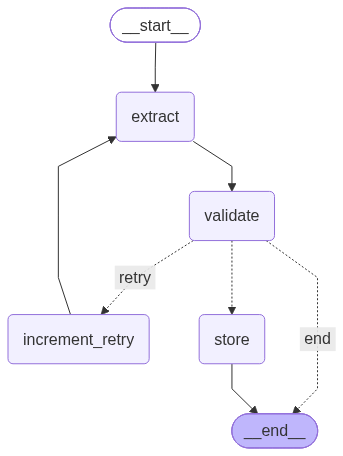

In [ ]:
langgraph_app

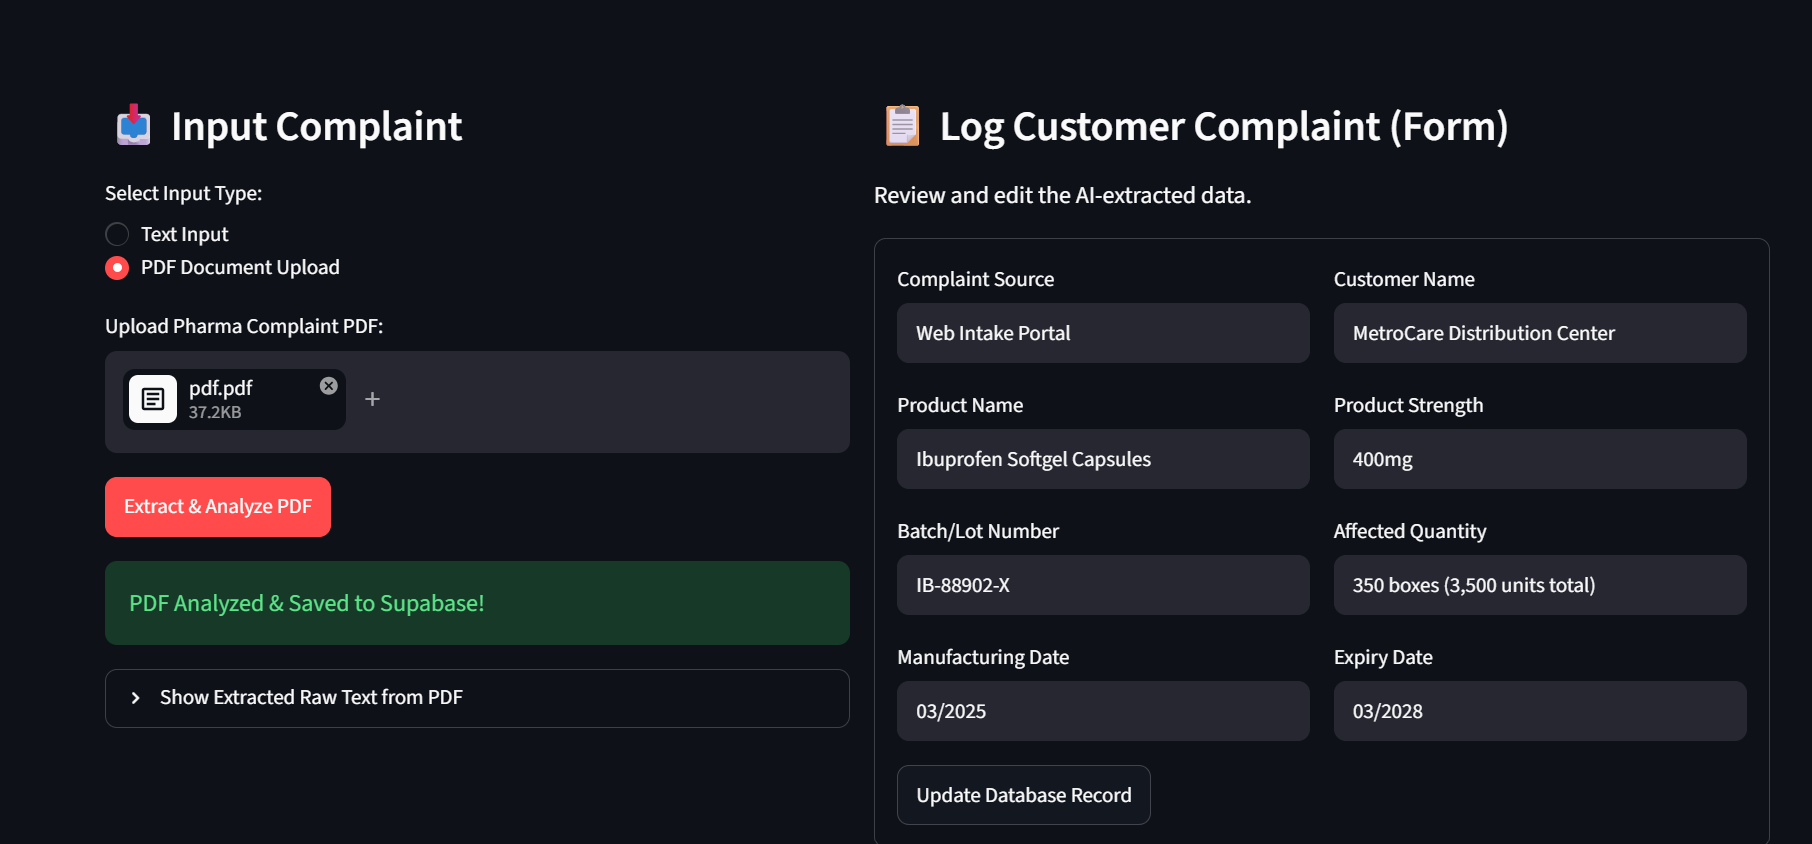